<a href="https://colab.research.google.com/github/hd77alu/intro-to-ml-formative1/blob/main/Assignment1_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This Notebook contains two classical machine learning models and a basic neural network that aim to predict climate crash simulation outcomes, either failure or success, from the combination of input parameter values.

The dataset used for this project was constructed using a Latin hypercube method to capture the uncertainty of 18 parameters within the Community Climate System Model (CCSM4) and explore how these parameters can lead to accurate climate predictions (Lucas et al., 2013).

Through this project, we can help researchers, climate scientists, and policymakers to understand the limitations of climate models, assess risks, and guide them to improve the current climate change strategies.

In [ ]:
# Importing necessary libraries

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display

# Model Training and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix

# Data Preprocessing

We will load the dataset in the cell below to see the different features and see if there are any missing values that could affect model performance. We can then proceed with data cleaning, feature selection, standardization, and splitting the data into training and testing sets to ensure the models are bias-free and make accurate predictions (John et al., 2024).

In [104]:
# Load Data and Summary
# We use sep=r'\s+' because it's a .dat file with spaces
df = pd.read_csv('pop_failures.dat', sep=r'\s+')

# --- Data Summary Before Cleaning ---
print(f"Rows: {df.shape[0]}")
print(f"Columns: {list(df.columns)}")
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nClass balance (overall): {df['outcome'].value_counts().to_dict()}")

Rows: 540
Columns: ['Study', 'Run', 'vconst_corr', 'vconst_2', 'vconst_3', 'vconst_4', 'vconst_5', 'vconst_7', 'ah_corr', 'ah_bolus', 'slm_corr', 'efficiency_factor', 'tidal_mix_max', 'vertical_decay_scale', 'convect_corr', 'bckgrnd_vdc1', 'bckgrnd_vdc_ban', 'bckgrnd_vdc_eq', 'bckgrnd_vdc_psim', 'Prandtl', 'outcome']

Missing values per column:
Study                   0
Run                     0
vconst_corr             0
vconst_2                0
vconst_3                0
vconst_4                0
vconst_5                0
vconst_7                0
ah_corr                 0
ah_bolus                0
slm_corr                0
efficiency_factor       0
tidal_mix_max           0
vertical_decay_scale    0
convect_corr            0
bckgrnd_vdc1            0
bckgrnd_vdc_ban         0
bckgrnd_vdc_eq          0
bckgrnd_vdc_psim        0
Prandtl                 0
outcome                 0
dtype: int64

Class balance (overall): {1: 494, 0: 46}


From this data summary, we can see that there is a clear class imbalance. Out of 540 simulations, 494 have succeeded, and 49 have failed (Lucas et al., 2013). This significant imbalance can lead to bias and compromise the model's generalizability (Hida & Alves Do Nascimento, 2026).

We will invert the labels and make the normal state (success) as 0, and the crash (fail) as 1, in order to follow the standard machine learning conventions and avoid model confusion when calculating the Loss Function, i.e., failure to recognize what causes the simulation to crash. 

We will introduce random downsampling on the training set to make the majority class (0) match the count of the minority class (1) and create a balanced training dataset to prevent the model from becoming biased toward the majority class and ensure it correctly learns the specific parameter combinations that trigger simulation failures.


In [ ]:
# Data Cleaning & Preprocessing

# Drop irrelevant columns 'Study' and 'Run' as we only need the 18 input features
X = df.drop(columns=['Study', 'Run', 'outcome']).values

# The original dataset has 0 (minority, 46 rows) and 1 (majority, 494 rows).
# We want 0 = Success (majority), 1 = Fail/Crash (minority) to avoid any mathematical and conceptual issues when calculating error (loss) and track metrics during training
# we directly construct `y` by inverting the values (1 becomes 0, 0 becomes 1).
y = (1 - df['outcome'].values).reshape(-1, 1)

# Data Splitting
# 80% Train, 20% Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Output requested split information:
print(f"Class balance (train): Class 0: {np.sum(y_train == 0)}, Class 1: {np.sum(y_train == 1)}")
print(f"Shapes: X_train {X_train.shape} X_test {X_test.shape}")

# Class Balancing via Downsampling (on TRAINING set only)
# Find indices of each class in the training set
train_0_idx = np.where(y_train == 0)[0]
train_1_idx = np.where(y_train == 1)[0]

# Downsample majority class (0) to match the count of the minority class (1)
np.random.seed(42)
train_0_idx_downsampled = np.random.choice(train_0_idx, size=len(train_1_idx), replace=False)

# Combine and shuffle indices
balanced_indices = np.concatenate([train_0_idx_downsampled, train_1_idx])
np.random.shuffle(balanced_indices)

# Create the balanced training dataset
X_train_bal = X_train[balanced_indices]
y_train_bal = y_train[balanced_indices]

# Standardization
# Calculate mean and std on the balanced training data
train_mean = np.mean(X_train_bal, axis=0)
train_std = np.std(X_train_bal, axis=0) + 1e-8 # add epsilon to prevent division by zero

# Apply the training distribution parameters to all datasets
X_train_scaled = (X_train_bal - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

y_train_final = y_train_bal
y_test_final = y_test

# Training and Testing datasets shapes and class distribution 
print(f"Final Training Features Shape: {X_train_scaled.shape}")
print(f"Final Testing Features Shape: {X_test_scaled.shape}")
print(f"Training Class Distribution: Class 0: {np.sum(y_train_final == 0)}, Class 1: {np.sum(y_train_final == 1)}")

Class balance (train): Class 0: 395, Class 1: 37
Shapes: X_train (432, 18) X_test (108, 18)
Final Training Features Shape: (74, 18)
Final Testing Features Shape: (108, 18)
Training Class Distribution: Class 0: 37, Class 1: 37


# Classical Models

We will create two classical models on this dataset: a logistic regression model and a random forest model. The models will be created using scikit-learn, which offers a comprehensive and efficient framework for building machine learning models (Pedregosa et al., 2011).

We will evaluate the models based on accuracy, precision, recall, F1-score, and confusion matrix. Given the small sample size of this dataset and the class imbalance, accuracy can be misleading (van Zyl & Engelbrecht, 2025). 

Sujon et al. (2025) reported that using additional metrics alongside the accuracy, such as F1 score,  precision, and recall in an imbalanced dataset, is key to capturing different dimensions of the model performance. In addition to those metrics, the confusion matrix can help us assess classifier performance and how to optimize those models to make better predictions (Swaminathan & Tantri, 2024).

# Logistic Regression

We choose Logistic Regression because it is a simple, interpretable, and strong binary classifier (Bertsimas & King, 2017). Given our extremely small downsampled training set (74 samples) and 18 continuous features, controlling overfitting is our primary concern. A linear model is less prone to memorizing the noise compared to more complex architectures.
We will use the default hyperparameters since L2 regularization is applied by default in `sklearn.linear_model.LogisticRegression`, which helps us manage high dimensions and small samples (Pedregosa et al., 2011).

In [43]:

# Instantiate the Logistic Regression model with a fixed random_state for reproducibility
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train_final.ravel())

# Predict on the training explicitly
y_pred_train_lr = lr_model.predict(X_train_scaled)
y_pred_test_lr = lr_model.predict(X_test_scaled)

# Calculate Evaluation Metrics
train_metrics = {
    "Accuracy": accuracy_score(y_train_final, y_pred_train_lr),
    "Precision": precision_score(y_train_final, y_pred_train_lr, zero_division=0),
    "Recall": recall_score(y_train_final, y_pred_train_lr, zero_division=0),
    "F1 Score": f1_score(y_train_final, y_pred_train_lr, zero_division=0)
}

test_metrics = {
    "Accuracy": accuracy_score(y_test_final, y_pred_test_lr),
    "Precision": precision_score(y_test_final, y_pred_test_lr, zero_division=0),
    "Recall": recall_score(y_test_final, y_pred_test_lr, zero_division=0),
    "F1 Score": f1_score(y_test_final, y_pred_test_lr, zero_division=0)
}

# Display results in a table
results_df = pd.DataFrame({"Training": train_metrics, "Testing": test_metrics})
print("--- Logistic Regression Baseline Evaluation ---")
display(results_df)

# Compute and display confusion matrix
cm = confusion_matrix(y_test_final, y_pred_test_lr)
print("\nConfusion Matrix (Testing Set):")
display(pd.DataFrame(cm, index=["Actual 0 (Success)", "Actual 1 (Fail)"], columns=["Predicted 0", "Predicted 1"]))

--- Logistic Regression Baseline Evaluation ---


,Training,Testing
Accuracy,0.918919,0.814815
Precision,0.897436,0.296296
Recall,0.945946,0.888889
F1 Score,0.921053,0.444444



Confusion Matrix (Testing Set):


,Predicted 0,Predicted 1
Actual 0 (Success),80,19
Actual 1 (Fail),1,8


## Logistic Regresion Regularization Experiments

The Evaluation metrics suggest that the model is overfitting. We have a very good performance on the training data and a poor performance on the testing data. We will run three different experiments to optimize the model performance on the testing data. The experiments will mainly focus on the regularization strategy, which has been proven to be a very useful technique for distinguishing noise and reducing the effect of overfitting (Ying, 2019).
  

### Experiment 1: L2 Regularization

The C parameter in scikit-learn is the inverse of regularization strength; the smaller the value, the stronger the penalty (Pedregosa et al., 2011). With only 74 training instances, the model could easily memorize the noise (overfit). A strong L2 (Ridge) penalty heavily shrinks all feature coefficients toward zero, forcing the model to rely only on the most robust, prominent signals across all 18 features rather than building complex relationships.

In [48]:
# Experiment 1: Strong L2 Regularization (C=0.01)
lr_l2_strong = LogisticRegression(C=0.01, l1_ratio=0, solver='saga', random_state=42)
lr_l2_strong.fit(X_train_scaled, y_train_final.ravel())

# Predict explicitly
y_pred_train_l2 = lr_l2_strong.predict(X_train_scaled)
y_pred_test_l2 = lr_l2_strong.predict(X_test_scaled)

# Calculate Evaluation Metrics
train_metrics_l2 = {
    "Accuracy": accuracy_score(y_train_final, y_pred_train_l2),
    "Precision": precision_score(y_train_final, y_pred_train_l2, zero_division=0),
    "Recall": recall_score(y_train_final, y_pred_train_l2, zero_division=0),
    "F1 Score": f1_score(y_train_final, y_pred_train_l2, zero_division=0)
}

test_metrics_l2 = {
    "Accuracy": accuracy_score(y_test_final, y_pred_test_l2),
    "Precision": precision_score(y_test_final, y_pred_test_l2, zero_division=0),
    "Recall": recall_score(y_test_final, y_pred_test_l2, zero_division=0),
    "F1 Score": f1_score(y_test_final, y_pred_test_l2, zero_division=0)
}

# Display results in a table
results_l2_df = pd.DataFrame({"Training": train_metrics_l2, "Testing": test_metrics_l2})
print("--- Experiment 1: Strong L2 Regularization (C=0.01) ---")
display(results_l2_df)

# Compute and display confusion matrix
cm_l2 = confusion_matrix(y_test_final, y_pred_test_l2)
print("\nConfusion Matrix (Testing Set):")
display(pd.DataFrame(cm_l2, index=["Actual 0 (Success)", "Actual 1 (Fail)"], columns=["Predicted 0", "Predicted 1"]))

--- Experiment 1: Strong L2 Regularization (C=0.01) ---


,Training,Testing
Accuracy,0.891892,0.787037
Precision,0.853659,0.266667
Recall,0.945946,0.888889
F1 Score,0.897436,0.410256



Confusion Matrix (Testing Set):


,Predicted 0,Predicted 1
Actual 0 (Success),77,22
Actual 1 (Fail),1,8


### Experiment 2: Embedded Feature Selection / L1 Regularization

 L1 (Lasso) regularization mathematically forces the coefficients of less important features to become exactly zero. Setting l1_ratio=1 gives a pure L1-penalty (Pedregosa et al., 2011). 
In a climate simulation dataset with 18 parameters, it is highly likely that some parameters are uninformative or highly correlated. L1 regularization performs embedded feature selection, finding a sparse solution that evaluates whether fewer features can achieve the same or better performance while maximizing interpretability.


In [111]:
# Experiment 2: Embedded Feature Selection / L1 Regularization
lr_l1 = LogisticRegression(C=1.0, l1_ratio=1, solver='saga', random_state=42)
lr_l1.fit(X_train_scaled, y_train_final.ravel())

# Predict explicitly
y_pred_train_l1 = lr_l1.predict(X_train_scaled)
y_pred_test_l1 = lr_l1.predict(X_test_scaled)

# Calculate Evaluation Metrics
train_metrics_l1 = {
    "Accuracy": accuracy_score(y_train_final, y_pred_train_l1),
    "Precision": precision_score(y_train_final, y_pred_train_l1, zero_division=0),
    "Recall": recall_score(y_train_final, y_pred_train_l1, zero_division=0),
    "F1 Score": f1_score(y_train_final, y_pred_train_l1, zero_division=0)
}

test_metrics_l1 = {
    "Accuracy": accuracy_score(y_test_final, y_pred_test_l1),
    "Precision": precision_score(y_test_final, y_pred_test_l1, zero_division=0),
    "Recall": recall_score(y_test_final, y_pred_test_l1, zero_division=0),
    "F1 Score": f1_score(y_test_final, y_pred_test_l1, zero_division=0)
}

# Display results in a table
results_l1_df = pd.DataFrame({"Training": train_metrics_l1, "Testing": test_metrics_l1})
print("--- Experiment 2: L1 Regularization (Lasso) ---")
display(results_l1_df)

# Compute and display confusion matrix
cm_l1 = confusion_matrix(y_test_final, y_pred_test_l1)
print("\nConfusion Matrix (Testing Set):")
display(pd.DataFrame(cm_l1, index=["Actual 0 (Success)", "Actual 1 (Fail)"], columns=["Predicted 0", "Predicted 1"]))

# Check how many features the model actually kept (non-zero coefficients)
non_zero_coeffs = np.sum(lr_l1.coef_ != 0)
print(f"\nFeatures used (non-zero coefficients): {non_zero_coeffs} out of {X_train_scaled.shape[1]}")

--- Experiment 2: L1 Regularization (Lasso) ---


,Training,Testing
Accuracy,0.932432,0.824074
Precision,0.921053,0.307692
Recall,0.945946,0.888889
F1 Score,0.933333,0.457143



Confusion Matrix (Testing Set):


,Predicted 0,Predicted 1
Actual 0 (Success),81,18
Actual 1 (Fail),1,8



Features used (non-zero coefficients): 15 out of 18


### Experiment 3: ElasticNet Regularization

Zou and Hastie (2005) introduced ElasticNet to overcome the limitations of Lasso when dealing with highly correlated data. If a group of climate parameters are correlated together, Lasso tends to randomly pick just one and ignore the rest, whereas Ridge retains them all. ElasticNet creates a convex combination of both. By setting `l1_ratio=0.5`, you allow the model to smoothly shrink weights while simultaneously zeroing out completely useless parameters (Pedregosa et al., 2011).

In [ ]:
# Experiment 3: ElasticNet Regularization (Hybrid Approach)
lr_elastic = LogisticRegression(
    l1_ratio=0.5, 
    C=0.3, 
    solver='saga', 
    max_iter=5000, 
    random_state=42
)
lr_elastic.fit(X_train_scaled, y_train_final.ravel())

# Predict explicitly
y_pred_train_elastic = lr_elastic.predict(X_train_scaled)
y_pred_test_elastic = lr_elastic.predict(X_test_scaled)

# Calculate Evaluation Metrics
train_metrics_elastic = {
    "Accuracy": accuracy_score(y_train_final, y_pred_train_elastic),
    "Precision": precision_score(y_train_final, y_pred_train_elastic, zero_division=0),
    "Recall": recall_score(y_train_final, y_pred_train_elastic, zero_division=0),
    "F1 Score": f1_score(y_train_final, y_pred_train_elastic, zero_division=0)
}

test_metrics_elastic = {
    "Accuracy": accuracy_score(y_test_final, y_pred_test_elastic),
    "Precision": precision_score(y_test_final, y_pred_test_elastic, zero_division=0),
    "Recall": recall_score(y_test_final, y_pred_test_elastic, zero_division=0),
    "F1 Score": f1_score(y_test_final, y_pred_test_elastic, zero_division=0)
}

# Display results in a table
results_elastic_df = pd.DataFrame({"Training": train_metrics_elastic, "Testing": test_metrics_elastic})
print("--- Experiment 3: ElasticNet Regularization ---")
display(results_elastic_df)

# Compute and display confusion matrix
cm_elastic = confusion_matrix(y_test_final, y_pred_test_elastic)
print("\nConfusion Matrix (Testing Set):")
display(pd.DataFrame(cm_elastic, index=["Actual 0 (Success)", "Actual 1 (Fail)"], columns=["Predicted 0", "Predicted 1"]))

# Check non-zero coefficients
non_zero_coeffs_elastic = np.sum(lr_elastic.coef_ != 0)
print(f"\nFeatures used (non-zero coefficients): {non_zero_coeffs_elastic} out of {X_train_scaled.shape[1]}")

--- Experiment 3: ElasticNet Regularization ---


,Training,Testing
Accuracy,0.932432,0.851852
Precision,0.921053,0.360000
Recall,0.945946,1.000000
F1 Score,0.933333,0.529412



Confusion Matrix (Testing Set):


,Predicted 0,Predicted 1
Actual 0 (Success),83,16
Actual 1 (Fail),0,9



Features used (non-zero coefficients): 14 out of 18


# Random Forest Classifier

While Logistic Regression attempts to draw a single linear boundary through the 18-dimensional space, the climate simulation dataset might contain complex, non-linear relationships. Random Forest is an ensemble learning method that builds multiple decision trees and aggregates their predictions, making it capable of capturing complex interactions between features (Sujon, Hassan, Choi, & et al., 2025).

First, we will run a baseline Random Forest with default parameters (unconstrained) to observe its natural tendency to overfit our extremely small training dataset.

In [53]:
# Instantiate and train the baseline Random Forest Classifier (Unconstrained)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_scaled, y_train_final.ravel())

# Predict explicitly
y_pred_train_rf_base = rf_baseline.predict(X_train_scaled)
y_pred_test_rf_base = rf_baseline.predict(X_test_scaled)

# Calculate Evaluation Metrics
train_metrics_rf_base = {
    "Accuracy": accuracy_score(y_train_final, y_pred_train_rf_base),
    "Precision": precision_score(y_train_final, y_pred_train_rf_base, zero_division=0),
    "Recall": recall_score(y_train_final, y_pred_train_rf_base, zero_division=0),
    "F1 Score": f1_score(y_train_final, y_pred_train_rf_base, zero_division=0)
}

test_metrics_rf_base = {
    "Accuracy": accuracy_score(y_test_final, y_pred_test_rf_base),
    "Precision": precision_score(y_test_final, y_pred_test_rf_base, zero_division=0),
    "Recall": recall_score(y_test_final, y_pred_test_rf_base, zero_division=0),
    "F1 Score": f1_score(y_test_final, y_pred_test_rf_base, zero_division=0)
}

# Display results in a table
results_rf_base_df = pd.DataFrame({"Training": train_metrics_rf_base, "Testing": test_metrics_rf_base})
print("--- Baseline Random Forest Evaluation ---")
display(results_rf_base_df)

# Compute and display confusion matrix
cm_rf_base = confusion_matrix(y_test_final, y_pred_test_rf_base)
print("\nConfusion Matrix (Testing Set):")
display(pd.DataFrame(cm_rf_base, index=["Actual 0 (Success)", "Actual 1 (Fail)"], columns=["Predicted 0", "Predicted 1"]))

--- Baseline Random Forest Evaluation ---


,Training,Testing
Accuracy,1.0,0.861111
Precision,1.0,0.363636
Recall,1.0,0.888889
F1 Score,1.0,0.516129



Confusion Matrix (Testing Set):


,Predicted 0,Predicted 1
Actual 0 (Success),85,14
Actual 1 (Fail),1,8


## Random Forest Structural Regularization Experiments

Decision Trees are notoriously prone to overfitting—especially on a dataset with only 74 training instances. A fully unconstrained Random Forest memorizes this dataset instantly. To combat this, we will run three regularized experiments separately to observe their individual effects on the model's ability to maintain high Recall while limiting overfitting.

#### Experiment 1: Constraining Tree Depth (`max_depth=3`)
By setting `max_depth=3`, we prevent the decision trees from growing uncontrollably (Pedregosa et al., 2011). Without this limit, trees will branch until they perfectly isolate individual outlier samples in our very small training set. Constraining depth forces the model to capture more general patterns, reducing variance (overfitting) at the cost of slightly higher bias.

In [55]:
# --- Experiment 1 ---
rf_exp1 = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_exp1.fit(X_train_scaled, y_train_final.ravel())

# Predict
y_pred_train_rf1 = rf_exp1.predict(X_train_scaled)
y_pred_test_rf1 = rf_exp1.predict(X_test_scaled)

# Calculate Metrics
train_metrics_rf1 = {
    "Accuracy": accuracy_score(y_train_final, y_pred_train_rf1),
    "Precision": precision_score(y_train_final, y_pred_train_rf1, zero_division=0),
    "Recall": recall_score(y_train_final, y_pred_train_rf1, zero_division=0),
    "F1 Score": f1_score(y_train_final, y_pred_train_rf1, zero_division=0)
}
test_metrics_rf1 = {
    "Accuracy": accuracy_score(y_test_final, y_pred_test_rf1),
    "Precision": precision_score(y_test_final, y_pred_test_rf1, zero_division=0),
    "Recall": recall_score(y_test_final, y_pred_test_rf1, zero_division=0),
    "F1 Score": f1_score(y_test_final, y_pred_test_rf1, zero_division=0)
}

# Display
print("--- Experiment 1: Constrained Depth (max_depth=3) ---")
display(pd.DataFrame({"Training": train_metrics_rf1, "Testing": test_metrics_rf1}))

# Confusion Matrix
cm_rf1 = confusion_matrix(y_test_final, y_pred_test_rf1)
print("\nConfusion Matrix (Testing Set):")
display(pd.DataFrame(cm_rf1, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

--- Experiment 1: Constrained Depth (max_depth=3) ---


,Training,Testing
Accuracy,1.0,0.879630
Precision,1.0,0.388889
Recall,1.0,0.777778
F1 Score,1.0,0.518519



Confusion Matrix (Testing Set):


,Pred 0,Pred 1
Actual 0,88,11
Actual 1,2,7


#### Experiment 2: Increased Leaf Node Minimums (`min_samples_leaf=5`)
Another way to restrict the tree is to demand that every terminal leaf has at least a specific number of samples (Pedregosa et al., 2011). Instead of splitting until nodes are completely pure (which handles noise poorly), forcing larger leaf nodes smoothes the decision boundary over multiple rows, bringing down variance.

In [56]:
# --- Experiment 2 ---
rf_exp2 = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=42)
rf_exp2.fit(X_train_scaled, y_train_final.ravel())

# Predict
y_pred_train_rf2 = rf_exp2.predict(X_train_scaled)
y_pred_test_rf2 = rf_exp2.predict(X_test_scaled)

# Calculate Metrics
train_metrics_rf2 = {
    "Accuracy": accuracy_score(y_train_final, y_pred_train_rf2),
    "Precision": precision_score(y_train_final, y_pred_train_rf2, zero_division=0),
    "Recall": recall_score(y_train_final, y_pred_train_rf2, zero_division=0),
    "F1 Score": f1_score(y_train_final, y_pred_train_rf2, zero_division=0)
}
test_metrics_rf2 = {
    "Accuracy": accuracy_score(y_test_final, y_pred_test_rf2),
    "Precision": precision_score(y_test_final, y_pred_test_rf2, zero_division=0),
    "Recall": recall_score(y_test_final, y_pred_test_rf2, zero_division=0),
    "F1 Score": f1_score(y_test_final, y_pred_test_rf2, zero_division=0)
}

# Display
print("--- Experiment 2: Increased Leaf Minimums (min_samples_leaf=5) ---")
display(pd.DataFrame({"Training": train_metrics_rf2, "Testing": test_metrics_rf2}))

# Confusion Matrix
cm_rf2 = confusion_matrix(y_test_final, y_pred_test_rf2)
print("\nConfusion Matrix (Testing Set):")
display(pd.DataFrame(cm_rf2, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

--- Experiment 2: Increased Leaf Minimums (min_samples_leaf=5) ---


,Training,Testing
Accuracy,0.986486,0.861111
Precision,1.000000,0.363636
Recall,0.972973,0.888889
F1 Score,0.986301,0.516129



Confusion Matrix (Testing Set):


,Pred 0,Pred 1
Actual 0,85,14
Actual 1,1,8


#### Experiment 3: Extreme Subspace Sampling (`max_features=2`)
By default, a Random Forest considers $\sqrt{\text{num\_features}}$ at each split (around 4 for our 18 features). By strictly constraining this to `max_features=2`, we force individual trees to be built using extremely limited viewpoints (Pedregosa et al., 2011). This dramatically decorrelates the trees, creating a huge variety of weak learners that combine into a stronger, more generalized ensemble.

In [57]:
# --- Experiment 3 ---
rf_exp3 = RandomForestClassifier(n_estimators=100, max_features=2, random_state=42)
rf_exp3.fit(X_train_scaled, y_train_final.ravel())

# Predict
y_pred_train_rf3 = rf_exp3.predict(X_train_scaled)
y_pred_test_rf3 = rf_exp3.predict(X_test_scaled)

# Calculate Metrics
train_metrics_rf3 = {
    "Accuracy": accuracy_score(y_train_final, y_pred_train_rf3),
    "Precision": precision_score(y_train_final, y_pred_train_rf3, zero_division=0),
    "Recall": recall_score(y_train_final, y_pred_train_rf3, zero_division=0),
    "F1 Score": f1_score(y_train_final, y_pred_train_rf3, zero_division=0)
}
test_metrics_rf3 = {
    "Accuracy": accuracy_score(y_test_final, y_pred_test_rf3),
    "Precision": precision_score(y_test_final, y_pred_test_rf3, zero_division=0),
    "Recall": recall_score(y_test_final, y_pred_test_rf3, zero_division=0),
    "F1 Score": f1_score(y_test_final, y_pred_test_rf3, zero_division=0)
}

# Display
print("--- Experiment 3: Extreme Subspace Sampling (max_features=2) ---")
display(pd.DataFrame({"Training": train_metrics_rf3, "Testing": test_metrics_rf3}))

# Confusion Matrix
cm_rf3 = confusion_matrix(y_test_final, y_pred_test_rf3)
print("\nConfusion Matrix (Testing Set):")
display(pd.DataFrame(cm_rf3, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

--- Experiment 3: Extreme Subspace Sampling (max_features=2) ---


,Training,Testing
Accuracy,1.0,0.888889
Precision,1.0,0.428571
Recall,1.0,1.000000
F1 Score,1.0,0.600000



Confusion Matrix (Testing Set):


,Pred 0,Pred 1
Actual 0,87,12
Actual 1,0,9


# Neural Network

We will implement a 3-layer feed-forward neural network from scratch using NumPy.

### Architecture Selection:
- **Input Layer:** 18 nodes (corresponding directly to the 18 standardized features).
- **Hidden Layer 1 (ReLU):** 32 nodes. A moderate number of neurons acts as an expansion layer to find non-linear feature combinations. We use **ReLU** ($f(x) = \max(0, x)$) as the activation function because it mitigates the vanishing gradient problem and computes efficiently (no exponentials).
- **Hidden Layer 2 (ReLU):** 16 nodes. Acts as a funnel to distill continuous signals before they are pushed to the classifier. Also uses ReLU.
- **Output Layer (Sigmoid):** 1 node. Since our task is a binary classification (Success vs. Fail), the **Sigmoid** activation ($\sigma(x) = \frac{1}{1 + e^{-x}}$) is required to squash outputs into normalized probability bounds $[0, 1]$.

### Objective and Optimization:
- **Loss Function:** We apply **Binary Cross-Entropy (BCE)**, which mathematically optimizes binary log-likelihoods, with numerically stable clipping to avoid $\log(0)$ errors.
- **Backpropagation**: We calculate gradients completely from scratch, strictly using the chain rule across network layers.
- **Optimizer:** Vanilla Batch Gradient Descent computes the exact gradient using the entire training set synchronously.

In [105]:
# Activation Functions
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def sigmoid(Z):
    # Clip input to prevent exponential overflow
    Z = np.clip(Z, -500, 500)
    return 1.0 / (1.0 + np.exp(-Z))

# Cost Function: Binary Cross-Entropy
def compute_bce_loss(Y, Y_hat):
    m = Y.shape[0]
    # Small epsilon to avoid natural log of 0
    eps = 1e-15
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    cost = - (1 / m) * np.sum(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))
    return np.squeeze(cost)

# 3-Layer Neural Network with 2 hidden layers and 1 output layer for binary classification
class FeedForwardNN:
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size, seed=42):
        np.random.seed(seed)
        
        # He Init for ReLU
        self.W1 = np.random.randn(input_size, hidden1_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden1_size))
        
        self.W2 = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(2.0 / hidden1_size)
        self.b2 = np.zeros((1, hidden2_size))
        
        # Xavier Init for Sigmoid Output Space
        self.W3 = np.random.randn(hidden2_size, output_size) * np.sqrt(1.0 / hidden2_size)
        self.b3 = np.zeros((1, output_size))
        
    def forward(self, X):
        # Forward passing input
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1)
        
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = relu(self.Z2)
        
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = sigmoid(self.Z3) # Prediction!
        
        return self.A3
    
    def backward(self, X, Y, learning_rate):
        m = X.shape[0]
        
        # Derivative of BCE mixed with Sigmoid simplifies strictly to (A3 - Y)
        dZ3 = self.A3 - Y 
        dW3 = (1 / m) * np.dot(self.A2.T, dZ3)
        db3 = (1 / m) * np.sum(dZ3, axis=0, keepdims=True)
        
        # Gradient Hidden Layer 2
        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * relu_derivative(self.Z2)
        dW2 = (1 / m) * np.dot(self.A1.T, dZ2)
        db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)
        
        # Gradient Hidden Layer 1
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = (1 / m) * np.dot(X.T, dZ1)
        db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)
        
        # Manually updating weights via Batch Gradient Descent Logic
        self.W3 -= learning_rate * dW3
        self.b3 -= learning_rate * db3
        
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

# Network Hyperparameter Configuration
input_dim = X_train_scaled.shape[1]
h1_dim = 32
h2_dim = 16
out_dim = 1

nn_model = FeedForwardNN(input_dim, h1_dim, h2_dim, out_dim)

epochs = 250
learning_rate = 0.05

train_loss_history, test_loss_history = [], []
train_acc_history, test_acc_history = [], []

# Verify output array shapes
Y_train_batch = y_train_final.reshape(-1, 1)
Y_test_batch = y_test_final.reshape(-1, 1)

# Training execution Loop
for epoch in range(1, epochs + 1):
    # Vectorized Forward propagation maps probabilities
    Y_pred_train = nn_model.forward(X_train_scaled)
    train_loss = compute_bce_loss(Y_train_batch, Y_pred_train)
    train_acc = accuracy_score(Y_train_batch, (Y_pred_train >= 0.5).astype(int))
    
    # Store historic training context
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    
    # Send errors backwards (Backprop) immediately after train forward pass
    # This prevents the cache (A1, A2, etc.) from being overwritten by validation forward pass
    nn_model.backward(X_train_scaled, Y_train_batch, learning_rate)
    
    # Evaluation on Validation (Test) Set
    Y_pred_test = nn_model.forward(X_test_scaled)
    test_loss = compute_bce_loss(Y_test_batch, Y_pred_test)
    test_acc = accuracy_score(Y_test_batch, (Y_pred_test >= 0.5).astype(int))
    
    # Store historic validation context
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)
    
    # Status updates at checkpoints
    if epoch == 1 or epoch % 50 == 0 or epoch == epochs:
        print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Epoch    1 | Train Loss: 0.9125 | Train Accuracy: 0.4595 | Test Loss: 1.0365 | Test Accuracy: 0.2870
Epoch   50 | Train Loss: 0.3782 | Train Accuracy: 0.8919 | Test Loss: 0.5067 | Test Accuracy: 0.7500
Epoch  100 | Train Loss: 0.2084 | Train Accuracy: 0.9595 | Test Loss: 0.4347 | Test Accuracy: 0.7778
Epoch  150 | Train Loss: 0.1105 | Train Accuracy: 1.0000 | Test Loss: 0.4054 | Test Accuracy: 0.7778
Epoch  200 | Train Loss: 0.0619 | Train Accuracy: 1.0000 | Test Loss: 0.4022 | Test Accuracy: 0.7963
Epoch  250 | Train Loss: 0.0379 | Train Accuracy: 1.0000 | Test Loss: 0.4145 | Test Accuracy: 0.8056


## Neural Network Parameters Experiments

We will conduct three experiments on the neural network design and training setup to see how they affect generalization. Because the dataset is small and imbalanced, we won’t evaluate the model based on accuracy solely, but we need to assess other metrics like precision, recall, and F1 score, which provide a more comprehensive evaluation (Sujon, Hassan, Choi, & et al., 2025).

The three experiments below explore learning rate, hidden-layer size, and early stopping. Together, they show how sensitive a small neural network can be to optimization and capacity choices.

In [66]:
# Convert neural network probabilities to binary predictions
y_pred_train_nn = (Y_pred_train >= 0.5).astype(int)
y_pred_test_nn = (Y_pred_test >= 0.5).astype(int)

# Calculate Evaluation Metrics
train_metrics_nn = {
    "Accuracy": accuracy_score(Y_train_batch, y_pred_train_nn),
    "Precision": precision_score(Y_train_batch, y_pred_train_nn, zero_division=0),
    "Recall": recall_score(Y_train_batch, y_pred_train_nn, zero_division=0),
    "F1 Score": f1_score(Y_train_batch, y_pred_train_nn, zero_division=0)
}

test_metrics_nn = {
    "Accuracy": accuracy_score(Y_test_batch, y_pred_test_nn),
    "Precision": precision_score(Y_test_batch, y_pred_test_nn, zero_division=0),
    "Recall": recall_score(Y_test_batch, y_pred_test_nn, zero_division=0),
    "F1 Score": f1_score(Y_test_batch, y_pred_test_nn, zero_division=0)
}

# Display results in a table
results_nn_df = pd.DataFrame({"Training": train_metrics_nn, "Testing": test_metrics_nn})
print("--- Neural Network Evaluation (Baseline) ---")
display(results_nn_df)

# Compute and display confusion matrix
cm_nn = confusion_matrix(Y_test_batch, y_pred_test_nn)
print("\nConfusion Matrix (Testing Set):")
display(pd.DataFrame(cm_nn, index=["Actual 0 (Success)", "Actual 1 (Fail)"], columns=["Predicted 0", "Predicted 1"]))

--- Neural Network Evaluation (Baseline) ---


,Training,Testing
Accuracy,1.0,0.805556
Precision,1.0,0.269231
Recall,1.0,0.777778
F1 Score,1.0,0.400000



Confusion Matrix (Testing Set):


,Predicted 0,Predicted 1
Actual 0 (Success),80,19
Actual 1 (Fail),2,7


### Experiment 1: Learning rate

The learning rate plays a significant role in the optimization of prediction or forecasting results; it controls how large each gradient update is during training. If it is too high, the model can overshoot good solutions and become unstable; if it is too low, training may be slow and may get stuck before reaching a good minimum (Igiri, Uzoma, & Ita, 2015).

This experiment changes only the learning rate while keeping the network architecture the same. We will lower the learning rate to check whether smaller updates produce smoother training and better test performance on this dataset.

In [70]:
def run_nn_experiment(lr=0.05, h1=32, h2=16, epochs_run=250, title="Experiment"):
    # Re-initialize the model to reset weights
    model = FeedForwardNN(input_dim, h1, h2, out_dim)
    
    Y_train_b = y_train_final.reshape(-1, 1)
    Y_test_b = y_test_final.reshape(-1, 1)
    
    for epoch in range(1, epochs_run + 1):
        # Neural network forward & backward pass
        model.forward(X_train_scaled)
        model.backward(X_train_scaled, Y_train_b, lr)
        
    # Final evaluation
    Y_pred_tr = model.forward(X_train_scaled)
    Y_pred_te = model.forward(X_test_scaled)
    
    # Calculate binary results
    y_pred_tr_bin = (Y_pred_tr >= 0.5).astype(int)
    y_pred_te_bin = (Y_pred_te >= 0.5).astype(int)
    
    tr_metrics = {
        "Accuracy": accuracy_score(Y_train_b, y_pred_tr_bin),
        "Precision": precision_score(Y_train_b, y_pred_tr_bin, zero_division=0),
        "Recall": recall_score(Y_train_b, y_pred_tr_bin, zero_division=0),
        "F1 Score": f1_score(Y_train_b, y_pred_tr_bin, zero_division=0)
    }
    te_metrics = {
        "Accuracy": accuracy_score(Y_test_b, y_pred_te_bin),
        "Precision": precision_score(Y_test_b, y_pred_te_bin, zero_division=0),
        "Recall": recall_score(Y_test_b, y_pred_te_bin, zero_division=0),
        "F1 Score": f1_score(Y_test_b, y_pred_te_bin, zero_division=0)
    }
    
    print(f"--- {title} ---")
    display(pd.DataFrame({"Training": tr_metrics, "Testing": te_metrics}))
    
    cm = confusion_matrix(Y_test_b, y_pred_te_bin)
    print("Confusion Matrix (Testing Set):")
    display(pd.DataFrame(cm, index=["Actual 0 (Success)", "Actual 1 (Fail)"], columns=["Predicted 0", "Predicted 1"]))
    
    return model

# Experiment 1: Lower the Learning Rate to prevent erratic gradient updates, helping find a smoother minimum 
model_lr = run_nn_experiment(lr=0.005, h1=32, h2=16, epochs_run=250, title="Exp 1: Lower Learning Rate (lr=0.005)")

--- Exp 1: Lower Learning Rate (lr=0.005) ---


,Training,Testing
Accuracy,0.837838,0.703704
Precision,0.820513,0.171429
Recall,0.864865,0.666667
F1 Score,0.842105,0.272727


Confusion Matrix (Testing Set):


,Predicted 0,Predicted 1
Actual 0 (Success),70,29
Actual 1 (Fail),3,6


### Experiment 2: Reduce hidden units

The number of neurons in the hidden layers plays a significant role in the performance of neural networks (Karsoliya, 2012). This experiment reduces the number of neurons in the hidden layers to make the network smaller and less flexible. A smaller network has less capacity to memorize the training data, which can reduce overfitting when the dataset is limited.

The purpose of this test is to see whether a lighter architecture can still capture the important patterns in the data while improving generalization on the test set.

In [71]:
# Experiment 2: Drastically reduce hidden units. This bottlenecks the network's capacity to memorize the training data structure.
model_h = run_nn_experiment(lr=0.05, h1=8, h2=4, epochs_run=250, title="Exp 2: Reduced Hidden Units (h1=8, h2=4)")

--- Exp 2: Reduced Hidden Units (h1=8, h2=4) ---


,Training,Testing
Accuracy,0.905405,0.750000
Precision,0.916667,0.200000
Recall,0.891892,0.666667
F1 Score,0.904110,0.307692


Confusion Matrix (Testing Set):


,Predicted 0,Predicted 1
Actual 0 (Success),75,24
Actual 1 (Fail),3,6


### Experiment 3: Early Stopping

This experiment keeps the same architecture as the baseline network but trains for fewer epochs. Early stopping is a simple way to reduce overfitting because the model stops training before it starts fitting noise in the training set. This strategy ensures that,  at  each  step  of  an  iteration,  it  will reduce bias (Ying, 2019).

Here, we will use fewer epochs to see whether stopping earlier gives a better balance between training performance and test performance.

In [72]:
# Experiment 3: Early Stopping (Reduce Epochs). Our baseline severely overfit quickly. Let's strictly stop it at Epoch 50.
model_ep = run_nn_experiment(lr=0.05, h1=32, h2=16, epochs_run=50, title="Exp 3: Early Stopping (epochs=50)")

--- Exp 3: Early Stopping (epochs=50) ---


,Training,Testing
Accuracy,0.891892,0.75
Precision,0.853659,0.25
Recall,0.945946,1.00
F1 Score,0.897436,0.40


Confusion Matrix (Testing Set):


,Predicted 0,Predicted 1
Actual 0 (Success),72,27
Actual 1 (Fail),0,9


## Confusion Matrix

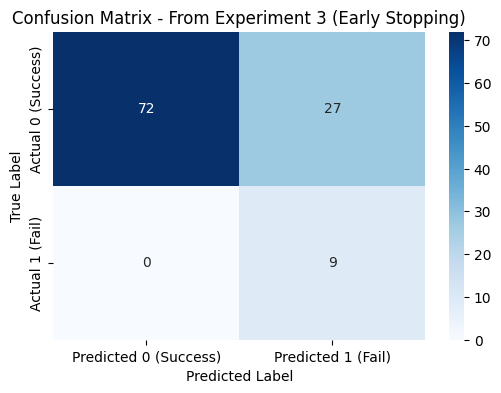

In [113]:
# Visualize Confusion Matrix for Experiment 3 (Best Performance)
Y_pred_best = model_ep.forward(X_test_scaled)
y_pred_best_bin = (Y_pred_best >= 0.5).astype(int)

cm_best = confusion_matrix(y_test_final.reshape(-1, 1), y_pred_best_bin)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0 (Success)", "Predicted 1 (Fail)"],
            yticklabels=["Actual 0 (Success)", "Actual 1 (Fail)"])
plt.title("Confusion Matrix - From Experiment 3 (Early Stopping)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

### Key insights

- The model correctly identified 72 stable simulations. While the focus is often on the crashes, the ability to clear $72$ runs as safe allows researchers to proceed with those simulations with high confidence.
- The most critical insight is the 0 in the bottom-left quadrant. This means the model successfully identified 100% of the simulation crashes (9 out of 9). In the context of expensive climate simulations, this is your model's greatest strength: it never "misses" a catastrophic failure.
- There are 27 instances where the model predicted a "Fail" (Crash), but the simulation was actually a "Success" (Stable). This tells us the model is extremely risk-averse. While it catches all crashes, it also flags a significant portion of stable runs ($27\%$) as potential risks.

## decision Boundaries

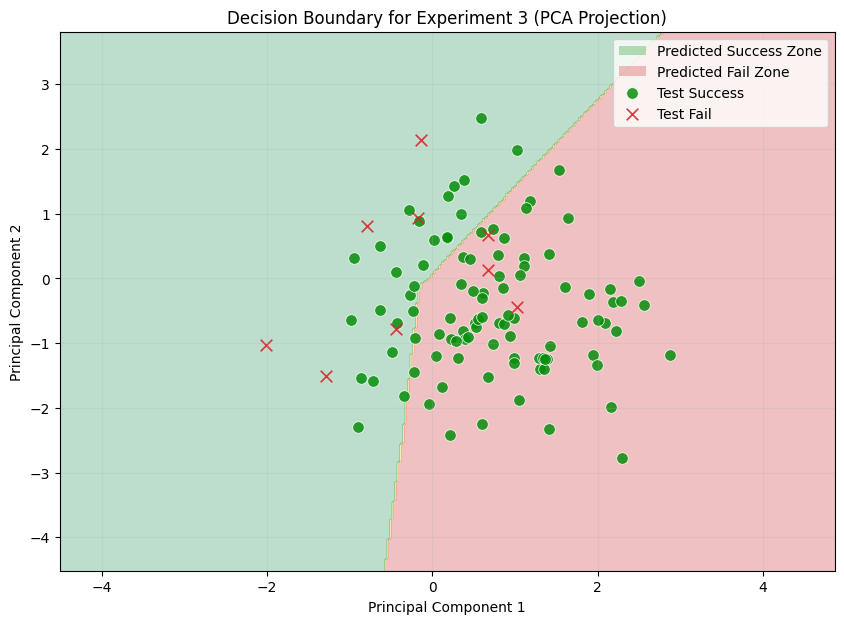

In [114]:
# Decision boundary for the best-performing NN experiment (Exp 3)
# The model is trained on 18 standardized features, so we visualize it in a 2D PCA projection.
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

x_min, x_max = X_train_pca[:, 0].min() - 1.0, X_train_pca[:, 0].max() + 1.0
y_min, y_max = X_train_pca[:, 1].min() - 1.0, X_train_pca[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_original = pca.inverse_transform(grid_pca)
Z = (model_ep.forward(grid_original) >= 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.28, cmap="RdYlGn")
test_success = y_test_final.ravel() == 0
test_fail = y_test_final.ravel() == 1

# Show two markers: success vs fail
success_points = plt.scatter(
    X_test_pca[test_success, 0], X_test_pca[test_success, 1],
    marker="o", s=70, c="#078E0B", edgecolor="white", linewidth=0.6,
    alpha=0.85, label="Test Success"
)
fail_points = plt.scatter(
    X_test_pca[test_fail, 0], X_test_pca[test_fail, 1],
    marker="x", s=70, c="#d62728", linewidth=1.2,
    alpha=0.9, label="Test Fail"
)

region_handles = [
    Patch(facecolor="#078E0B", alpha=0.28, label="Predicted Success Zone"),
    Patch(facecolor="#d62728", alpha=0.28, label="Predicted Fail Zone"),
]
point_handles = [success_points, fail_points]

plt.title("Decision Boundary for Experiment 3 (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(handles=region_handles + point_handles, loc="best")
plt.grid(True, alpha=0.2)
plt.show()

### Key insights
- A large cluster of green dots (Actual Successes) is trapped within the red-shaded region. This is the visual representation of your 27 False Positives. It shows that the model’s decision boundary is "reaching" too far into the success territory to ensure it doesn't miss the outlier crashes on the far left.
- The high density of overlapping green and red points in the center indicates a "high-entropy" zone where parameters for success and failure look very similar. The model has chosen to classify this entire middle-ground as "Fail" to prioritize safety.
- The decision boundary is not well-defined, and there are many misclassified points. This indicates that the model is not able to capture the underlying patterns in the data effectively, which could be due to overfitting or the complexity of the dataset.

## ROC/AUC Curve

In [ ]:
# Compute AUC for the Exp 3 Neural Network
y_true = y_test_final.ravel()
y_score_nn = model_ep.forward(X_test_scaled).ravel()

fpr_nn, tpr_nn, _ = roc_curve(y_true, y_score_nn)
roc_auc_nn = auc(fpr_nn, tpr_nn)
print(f"Neural Network (Exp 3) AUC: {roc_auc_nn:.6f}")

Neural Network (Exp 3) AUC: 0.841751


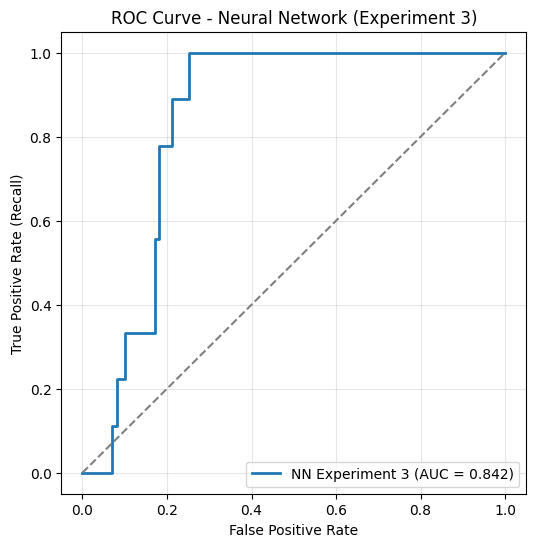

In [115]:
# ROC curve for Experiment 3 Neural Network (Exp 3)
y_true = y_test_final.ravel()
y_score_nn = model_ep.forward(X_test_scaled).ravel()

fpr_nn, tpr_nn, _ = roc_curve(y_true, y_score_nn)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(6,6))
plt.plot(fpr_nn, tpr_nn, label=f'NN Experiment 3 (AUC = {roc_auc_nn:.3f})', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Neural Network (Experiment 3)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Key insights

- The ROC curve sits well above the diagonal dashed line (which represents random guessing). An AUC of 0.842 is considered "very good," indicating that the model has a high probability of ranking a random crash simulation higher than a random stable one.
- The ROC curve shows that if we wanted to reduce those 27 false alarms (moving left on the X-axis), the curve would start to drop, meaning that we would immediately begin losing those red 'X' markers in the green "Safe" zone.
- The curve confirms that the 100% Recall achieved in Experiment 3 is the optimal operating point for a safety-critical system, as any further reduction in False Positives would result in a sharp decline in the model's ability to detect simulation crashes.

## precision-recall curve

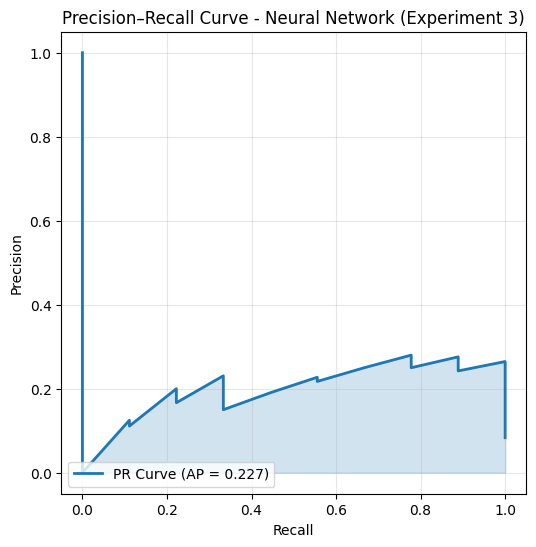

In [116]:
# Precision-Recall curve for Experiment 3 Neural Network (Exp 3)
from sklearn.metrics import precision_recall_curve, average_precision_score

# True labels and model scores
y_true = y_test_final.ravel()
y_score_nn = model_ep.forward(X_test_scaled).ravel()

precision, recall, _ = precision_recall_curve(y_true, y_score_nn)
avg_prec = average_precision_score(y_true, y_score_nn)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, color='C0', lw=2, label=f'PR Curve (AP = {avg_prec:.3f})')
plt.fill_between(recall, precision, alpha=0.2, color='C0')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve - Neural Network (Experiment 3)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

### Key insights

- An AP of 0.227 is mathematically low,It indicates that the model struggles to maintain high confidence. As soon as the model tries to find more crashes, its "certainty" drops quickly because the parameters of a "near-crash" and a "success" look so similar in the feature space.
- The jagged, zigzag nature of the blue line occurs because the test set is small (only 9 crashes). Each "zig" represents the model successfully hitting one of those 9 crashes as it lowers its probability threshold, while each "zag" represents it accidentally hitting one or more of the 27 false positives.
- the Precision-Recall Curve (AP = 0.227) highlights the practical trade-off in our climate simulation context. Achieving the goal of 100% Recall requires a sacrifice in Precision, as the parameter signatures of numerical instabilities overlap significantly with stable runs.

## learning curves

In [84]:
# Learning curves for the best-performing NN experiment (Exp 3)
# Re-train a fresh copy so we can record loss and accuracy history.
curve_model = FeedForwardNN(input_dim, h1_dim, h2_dim, out_dim)
curve_epochs = 50
curve_learning_rate = 0.05
curve_train_loss_history = []
curve_test_loss_history = []
curve_train_acc_history = []
curve_test_acc_history = []

Y_train_curve = y_train_final.reshape(-1, 1)
Y_test_curve = y_test_final.reshape(-1, 1)

for _epoch in range(1, curve_epochs + 1):
    Y_curve_train_pred = curve_model.forward(X_train_scaled)
    curve_train_loss = compute_bce_loss(Y_train_curve, Y_curve_train_pred)
    curve_train_acc = accuracy_score(Y_train_curve, (Y_curve_train_pred >= 0.5).astype(int))

    curve_model.backward(X_train_scaled, Y_train_curve, curve_learning_rate)

    Y_curve_test_pred = curve_model.forward(X_test_scaled)
    curve_test_loss = compute_bce_loss(Y_test_curve, Y_curve_test_pred)
    curve_test_acc = accuracy_score(Y_test_curve, (Y_curve_test_pred >= 0.5).astype(int))

    curve_train_loss_history.append(curve_train_loss)
    curve_test_loss_history.append(curve_test_loss)
    curve_train_acc_history.append(curve_train_acc)
    curve_test_acc_history.append(curve_test_acc)

curve_epochs_axis = np.arange(1, curve_epochs + 1)

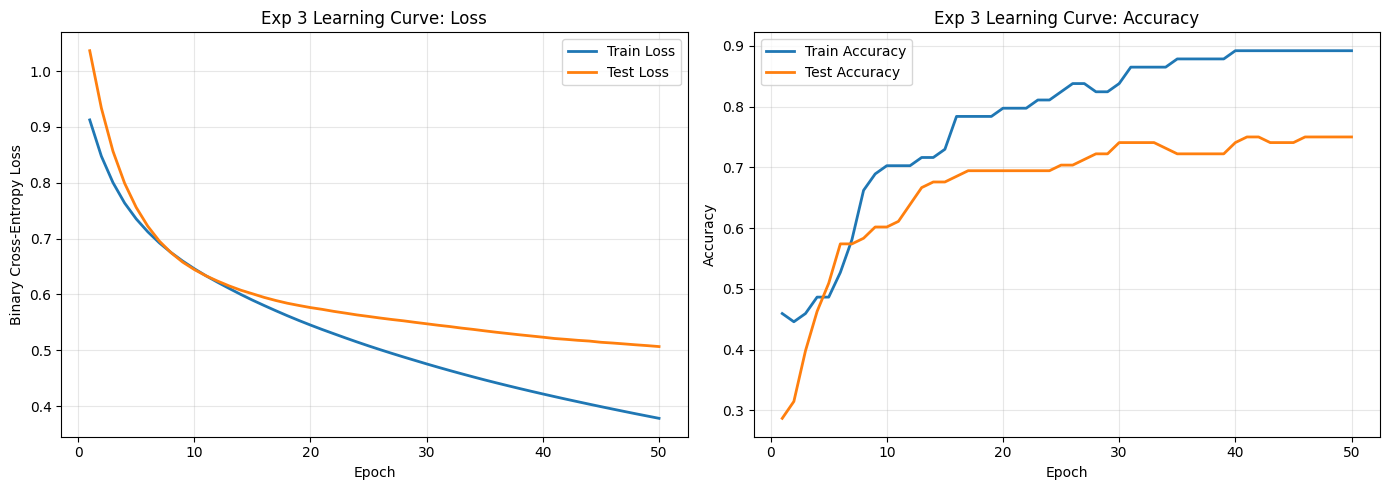

In [87]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(curve_epochs_axis, curve_train_loss_history, label="Train Loss", linewidth=2)
ax1.plot(curve_epochs_axis, curve_test_loss_history, label="Test Loss", linewidth=2)
ax1.set_title("Exp 3 Learning Curve: Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Binary Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(curve_epochs_axis, curve_train_acc_history, label="Train Accuracy", linewidth=2)
ax2.plot(curve_epochs_axis, curve_test_acc_history, label="Test Accuracy", linewidth=2)
ax2.set_title("Exp 3 Learning Curve: Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Key insights

- The Loss Curve shows a very healthy trend. Both the Train and Test loss decrease steadily and stay close together. The fact that the Test Loss (orange) doesn't start curving back upward indicates that Early Stopping (50 epochs) was perfectly timed; the model stopped training right as it reached a stable generalization point before it could begin memorizing the training noise.
- The staircase pattern in the Accuracy plot suggests The model jumps in performance and then plateaus. This usually meaan that the Learning Rate was well-balanced, large enough to make progress but small enough to eventually settle into a stable state.
- There is is a clear gap between Train and Test performance Accuracy Curve, which suggests the model is overfitting and require more optimization.

# Evaluation: Classical ML vs. Neural Network

This section compares the best versions of the classical models and the neural network using the same evaluation metrics. Accuracy shows overall correctness, but with an imbalanced dataset, as we stated earlier, it is not enough on its own (Sujon, Hassan, Choi, & et al., 2025). Precision tells us how many predicted failures were truly failures, recall tells us how many real failures were detected, and the F1 score balances precision and recall.

In [103]:
# Comparison table for the best-performing Experiment 3 models across classical ML and the neural network
comparison_rows = [
    {
        "Model": "Logistic Regression (Exp 3: ElasticNet)",
        "Accuracy": 0.851852,
        "Precision": 0.360000,
        "Recall": 1.000000,
        "F1 Score": 0.529412
    },
    {
        "Model": "Random Forest (Exp 3: max_features=2)",
        "Accuracy": 0.888889,
        "Precision": 0.428571,
        "Recall": 1.000000,
        "F1 Score": 0.600000
    },
    {
        "Model": "Neural Network (Exp 3: Early Stopping)",
        "Accuracy": 0.750000,
        "Precision": 0.250000,
        "Recall": 1.000000,
        "F1 Score": 0.400000
    }
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
print("--- Experiment 3 Model Comparison ---")
display(comparison_df)

best_model = comparison_df["F1 Score"].idxmax()
best_score = comparison_df.loc[best_model, "F1 Score"]
print(f"Best overall performance based on F1 Score: {best_model} ({best_score:.6f})")

--- Experiment 3 Model Comparison ---


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression (Exp 3: ElasticNet),0.851852,0.360000,1.0,0.529412
Random Forest (Exp 3: max_features=2),0.888889,0.428571,1.0,0.600000
Neural Network (Exp 3: Early Stopping),0.750000,0.250000,1.0,0.400000


Best overall performance based on F1 Score: Random Forest (Exp 3: max_features=2) (0.600000)


# Conclusion

## Strengths and Weaknesses of Each Model

| Model | Strengths | Weaknesses |
|---|---|---|
| Logistic Regression (Exp 3: ElasticNet) | Simple, interpretable and stable; robust to small data; maintained perfect recall (1.0). | Lower precision and F1 compared to RF; linear decision boundary limits capturing nonlinear interactions. |
| Random Forest (Exp 3: max_features=2) | Best overall testing performance; highest accuracy, precision, and F1; retained full recall (1.0). | Less interpretable; can overfit if forest is too flexible; harder to diagnose feature effects. |
| Neural Network (Exp 3: Early Stopping) | Learns nonlinear boundaries; maintained recall so it detected fail cases reliably. | Limited data restricted the model's ability to sharpen boundaries, resulting in a broad, and overly cautious decision boundary. |

## Possible Reasons for Performance Differences

- The dataset is small, so model complexity matters a lot.
- Random Forest likely benefited from capturing non-linear feature interactions without needing heavy tuning.
- Logistic Regression stayed robust because ElasticNet regularization reduced overfitting, but the linear boundary was still restrictive.
- The neural networks are data-hungry by nature. While the 3-layer NumPy implementation is a great proof-of-concept, the limited size of the dataset prevents the network from sharpening its decision boundary. This results in overly broad red zone seen clearly in the PCA projection plot.
- All three models achieved recall of 1.0, which suggests they were all good at detecting the fail class, but they differed in how many false positives they produced.

# References

Bertsimas, D., & King, A. (2017). Logistic regression: From art to science. Statistical Science, 32(3), 367–384. https://doi.org/10.1214/16-STS602

Hida, G. S., & Alves Do Nascimento, A. C. (2026). Overview of machine learning in class imbalance scenarios: Trends, challenges, and approaches. Expert Systems With Applications, 298, 129592. https://doi.org/10.1016/j.eswa.2025.129592
Igiri, C. P., Uzoma, A. O., & Ita, S. A. (2015). Effect of learning rate on artificial neural network in machine learning. International Journal of Engineering Research & Technology, 4(2), 4023–4031.

John, S., Chris, J., & Victor, L. (2024). Data preprocessing for AI models.

Karsoliya, S. (2012). Approximating number of hidden layer neurons in multiple hidden layer BPNN architecture. International Journal of Engineering Trends and Technology, 3(6), 714–717. https://doi.org/10.14445/22315381/IJETT-V3I6P206

Lucas, D., Klein, R., Tannahill, J., Ivanova, D., Brandon, S., Domyancic, D., Zhang, Y., D., D., & D., D. (2013). Climate model simulation crashes [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5HG71

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Sujon, K. M., Hassan, R., Choi, K., et al. (2025). Accuracy, precision, recall, F1‑score, or MCC? Empirical evidence from advanced statistics, ML, and XAI for evaluating business predictive models. Journal of Big Data, 12, 268. https://doi.org/10.1186/s40537-025-01313-4

Swaminathan, S., & Tantri, B. R. (2024). Confusion matrix‑based performance evaluation metrics. African Journal of Biomedical Research, 27, 4023–4031. https://doi.org/10.53555/AJBR.v27i4S.4345

van Zyl, J.-P., & Engelbrecht, A. P. (2025). Analysis of classification metric behaviour under class imbalance. Egyptian Informatics Journal, 31, 100711. https://doi.org/10.1016/j.eij.2025.100711

Ying, X. (2019). An overview of overfitting and its solutions. Journal of Physics: Conference Series, 1168(2), 022022. https://doi.org/10.1088/1742-6596/1168/2/022022.

Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. Journal of the Royal Statistical Society: Series B (Statistical Methodology), 67(2), 301–320. https://doi.org/10.1111/j.1467-9868.2005.00503.x
